In [1]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve
import nifty8.re as jft

from aim_resolve import Observation, SignalSpace, SignalModel, plot_arrays, check_type, optimize_kl

jax.config.update("jax_enable_x64", True)

key = jax.random.PRNGKey(123)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


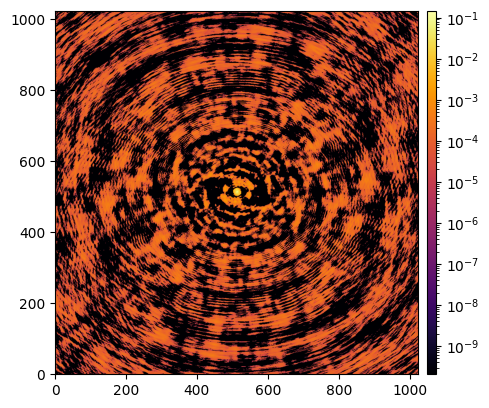

In [2]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()

space = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space)
kernel = compute_psf_kernel(RNR_l)

plot_arrays(kernel, norm='log', dpi=100)

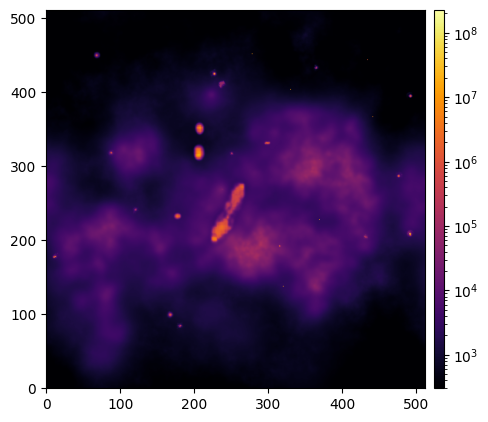

In [3]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')


sky_bg = optim_cfg.instantiate_sec('sky_bg.3')
sky_o0 = optim_cfg.instantiate_sec('sky_o0.3')
sky_o1 = optim_cfg.instantiate_sec('sky_o1.3')
sky_o2 = optim_cfg.instantiate_sec('sky_o2.3')
sky_t0 = optim_cfg.instantiate_sec('sky_t0.3')
sky_p0 = optim_cfg.instantiate_sec('sky_p0.3')


with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    samples, *_ = pickle.load(f)

rec_bg = samples.mean(sky_bg)
rec_o0 = map_signal(samples.mean(sky_o0), sky_o0.space, sky_bg.space)
rec_o1 = map_signal(samples.mean(sky_o1), sky_o1.space, sky_bg.space)
rec_o2 = map_signal(samples.mean(sky_o2), sky_o2.space, sky_bg.space)
rec_t0 = samples.mean(sky_t0)
rec_p0 = samples.mean(sky_p0)

rec = rec_bg + rec_o0 + rec_o1 + rec_o2 + rec_t0 + rec_p0

plot_arrays(rec, norm='log', vmin=3e2, vmax=rec.max(), dpi=100)

In [26]:
from jax import vmap
from jax.numpy.fft import fftn, ifftn
from jax.lax import dynamic_slice
from jax.scipy.signal import fftconvolve


def build_fft_kernel(kernel, shape, dvol=1.):
    return np.fft.fftn(kernel, shape) * dvol


def build_padder(in_shape, out_shape):
    p0, p1 = [(s - a) for s,a in zip(out_shape, in_shape)]
    return lambda x: jnp.pad(x, ((0, p0), (0, p1)))


def build_slicer(start_indices, out_shape):
    s0, s1 = start_indices
    return lambda x: dynamic_slice(x, (s0, s1), out_shape)


def scipy_fftconvolve(kernel, shape, dvol=1.):
    print('scipy fft shape:', tuple(s+k-1 for s,k in zip(shape, kernel.shape)))
    slicer = build_slicer(tuple(k//2 for k in kernel.shape), shape)
    return lambda x: slicer(fftconvolve(x, kernel, mode='full') * dvol)


def fast_fftconvolve(kernel, shape, dvol=1.):
    fft_kernel = build_fft_kernel(kernel, kernel.shape, dvol)
    fft_kernel = jnp.array(fft_kernel)
    print('fast fft shape:', fft_kernel.shape)

    padder = build_padder(shape, fft_kernel.shape)
    slicer = build_slicer(tuple(k//2 for k in kernel.shape), shape)

    def fun(x):
        x = padder(x)
        r = ifftn(fft_kernel * fftn(x)).real
        r = slicer(r)
        return r

    return fun


def downsample(array, factor):
    return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    

def upsample(array, factor):
    return array.repeat(factor, axis=0).repeat(factor, axis=1)


def build_split_kernel(kernel, shape, size, dvol=1., plot=False):
    fshape = tuple(s+size for s in shape)
    print('split fft shape:', fshape)

    fkernel = np.zeros((2,) +  fshape, dtype='complex128')
    for f in range(1, 3):
        if f == 1:
            slc_in = (slice(0, 0), slice(0, 0))
            slc_out = tuple(slice(k//2 - size//2, k//2 + size//2) for k in kernel.shape)
        else:
            slc_in = slc_out
            slc_out = tuple(slice(0, k) for k in kernel.shape)

        ker = np.array(kernel[slc_out])
        ker[slc_in] = 0

        if plot and f == 1:
            ker1 = ker.copy()
        if f == 2:
            ker = downsample(ker, f)
        
        fker = build_fft_kernel(ker, fshape, dvol * (f**2))
        fkernel[f-1] = fker

    if plot:
        plot_arrays([ker1, ker], label=['f=1 kernel', 'f=1/2 kernel'], rows=1, norm='log', vmin=1e-5, vmax=ker1.max())

    return fkernel


def split_fftconvolve(kernel, shape, size, dvol=1., plot=False):
    fft_kernels = build_split_kernel(kernel, shape, size, dvol, plot)
    fft_kernels = jnp.array(fft_kernels)

    padder1 = build_padder(shape, fft_kernels.shape[1:])
    padder2 = build_padder(tuple(s//2 for s in shape), fft_kernels.shape[1:])
    slicer1 = build_slicer((size//2,) * 2, shape)
    slicer2 = build_slicer(tuple(k//4 for k in kernel.shape), tuple(s//2 for s in shape))

    def fun(x):
        x1 = padder1(x)
        x2 = padder2(downsample(x, 2))
        xx = jnp.stack([x1, x2])
        rr = vmap(lambda ki,xi: ifftn(ki * fftn(xi)).real)(fft_kernels, xx)
        r1 = slicer1(rr[0])
        r2 = upsample(slicer2(rr[1]), 2)
        return r1 + r2

    return fun

scipy fft shape: (1535, 1535)
fast fft shape: (1024, 1024)
split fft shape: (640, 640)


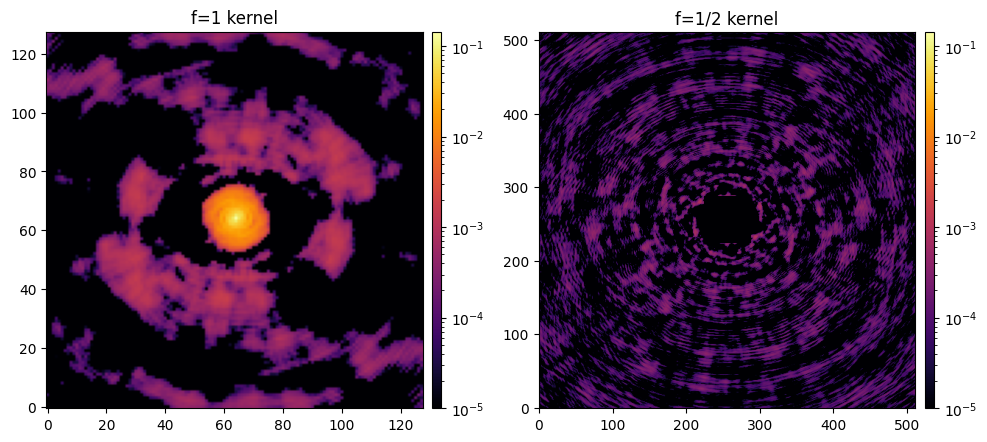

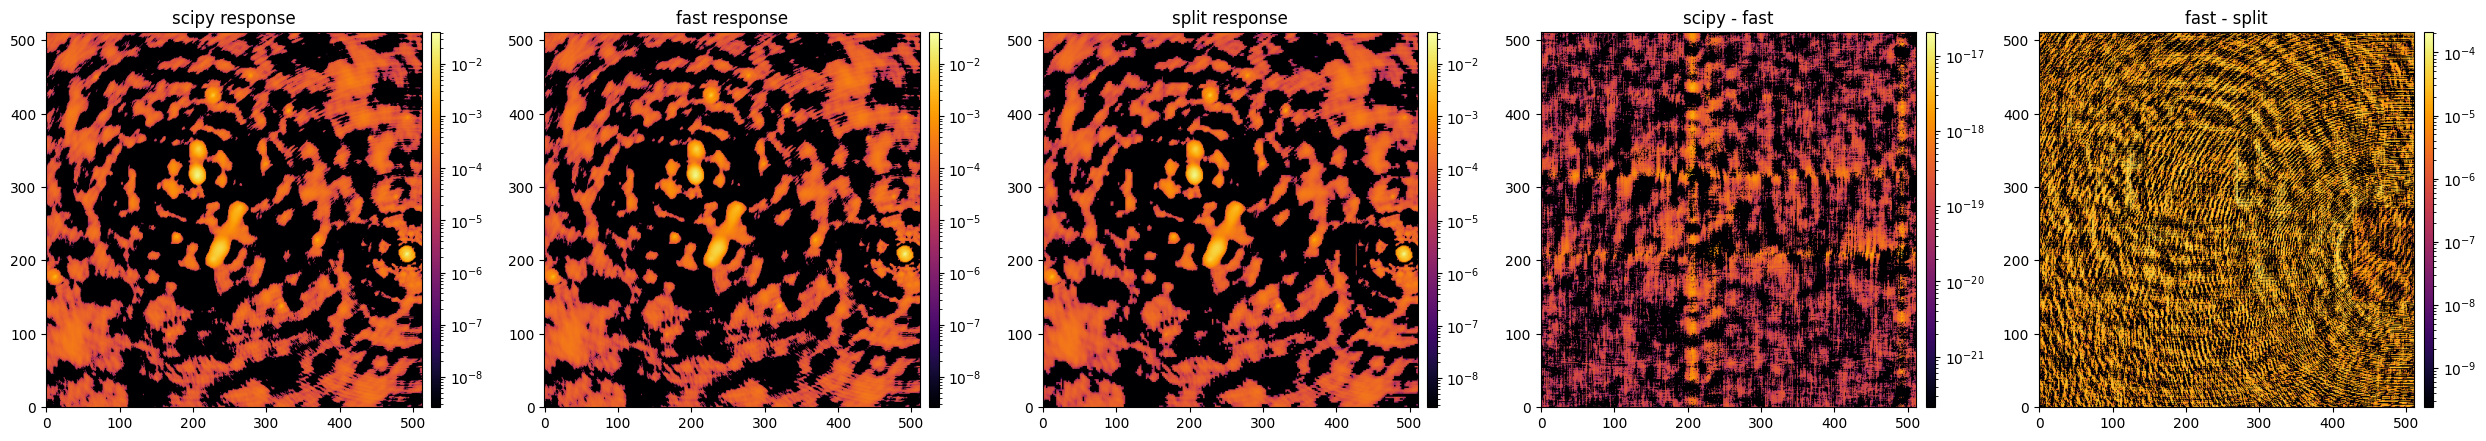

In [27]:
size = 128

scipy_res = scipy_fftconvolve(kernel, rec.shape, space.dis.prod())(rec)
fast_res = fast_fftconvolve(kernel, rec.shape, space.dis.prod())(rec)
split_res = split_fftconvolve(kernel, rec.shape, size, space.dis.prod(), True)(rec)

plot_arrays([scipy_res, fast_res, split_res, scipy_res-fast_res, fast_res-split_res], label=['scipy response', 'fast response', 'split response', 'scipy - fast', 'fast - split'], norm='log', rows=1)

fast fft shape: (1024, 1024)


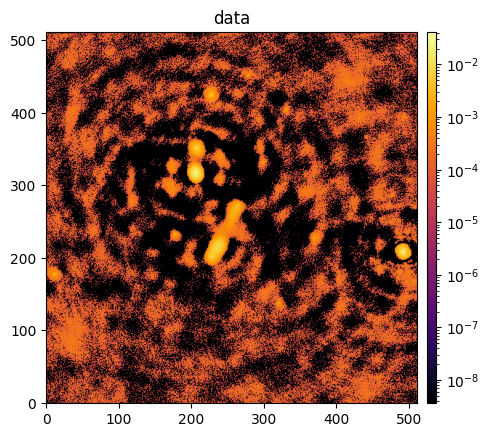

In [28]:
def generate_data(image, kernel, space, n_std=1e-4):
    truth = fast_fftconvolve(kernel, space.shape, space.dis.prod())(image)
    noise = n_std * jax.random.normal(key, truth.shape)
    data = truth + noise
    return data


data = generate_data(rec, kernel, space)

plot_arrays(data, label='data', rows=1, norm='log')

In [29]:
class ScipyResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.dvol = model.space.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return scipy_fftconvolve(self.kernel, self.shape, self.dvol)(self.model(x))
    


class FastResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.dvol = model.space.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return fast_fftconvolve(self.kernel, self.shape, self.dvol)(self.model(x))



class SplitResponse(jft.Model):
    def __init__(self, model, kernel, size):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.size = size
        self.dvol = model.space.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return split_fftconvolve(self.kernel, self.shape, self.size, self.dvol)(self.model(x))


scipy fft shape: (1535, 1535)
fast fft shape: (1024, 1024)
split fft shape: (576, 576)
scipy fft shape: (1535, 1535)
fast fft shape: (1024, 1024)
split fft shape: (576, 576)


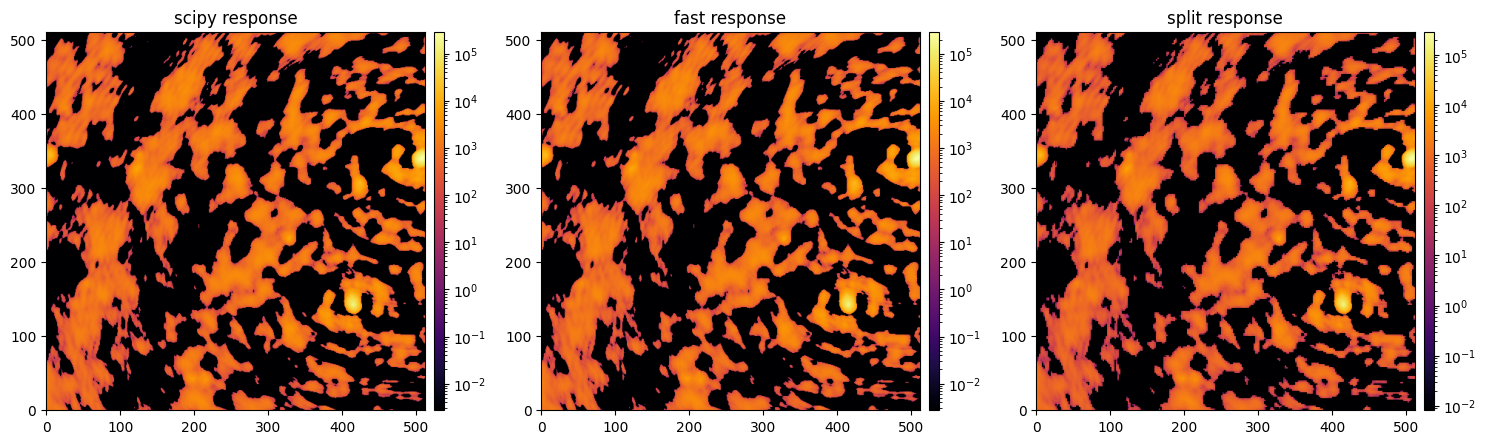

In [30]:
signal = SignalModel.build(
    prefix='sig',
    space=dict(
        shape=(512, 512),
        fov=('2deg', '2deg'),
    ),
    i0=dict(
        offset_mean=12,
        offset_std=(1,1),
        fluctuations=(5,1),
        loglogavgslope=(-2,0.5),
        flexibility=(1.2,0.4),
        asperity=(0.2,0.2),
    ),
)
size = 64

scipy_response = ScipyResponse(signal, kernel)

fast_response = FastResponse(signal, kernel)

split_response = SplitResponse(signal, kernel, size)


key, subkey = jax.random.split(key)
prior_xi = signal.init(subkey)

plot_arrays([scipy_response(prior_xi), fast_response(prior_xi), split_response(prior_xi)], label=['scipy response', 'fast response', 'split response'], rows=1, norm='log')

In [31]:
import time

def time_it(fun, image, kernel, **kwargs):
    jit_fun = jax.jit(fun(kernel, image.shape, **kwargs))

    start_time = time.time()
    _ = jit_fun(image).block_until_ready()
    elapsed_time = time.time() - start_time
    return elapsed_time


# Define a random input
shape = (1024, ) * 2
size = 64

s = jnp.ones(shape)
k = np.ones(tuple(2*s for s in shape))

scipy_time = time_it(scipy_fftconvolve, s, k, dvol=1.0)
fast_time = time_it(fast_fftconvolve, s, k, dvol=1.0)
split_time = time_it(split_fftconvolve, s, k, size=size, dvol=1.0)

print('scipy time:', scipy_time)
print('fast time:', fast_time)
print('split time:', split_time)

scipy fft shape: (3071, 3071)
fast fft shape: (2048, 2048)
split fft shape: (1088, 1088)
scipy time: 1.873157024383545
fast time: 1.2568912506103516
split time: 0.5906367301940918


OPTIMIZE_KL: Starting 0001


s == p == set()
fast fft shape: (1024, 1024)
fast fft shape: (1024, 1024)
fast fft shape: (1024, 1024)
fast fft shape: (1024, 1024)


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+1.3213e+05
OPTIMIZE_KL: #(KL minimization steps) 50
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.0±     0.0, avg:   +0.021±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
sig i0 asperity         :: 'reduced χ²: 1.6e-05±     0.0, avg:   +0.004±     0.0, #dof:      1'
sig i0 flexibility      :: 'reduced χ²:  0.0035±     0.0, avg:   +0.059±     0.0, #dof:      1'
sig i0 fluctuations     :: 'reduced χ²:     5.6±     0.0, avg:     +2.4±     0.0, #dof:      1'
sig i0 loglogavgslope   :: 'reduced χ²:    0.17±     0.0, avg:    +0.42±     0.0, #dof:      1'
sig i0 spectrum         :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0015±     0.0, #dof:  44048'
sig i0 xi               :: 'reduced χ²: 0.00025±     0.0, avg: +1.7e-06±     0.0, #dof: 262144'
sig i0 zeromode         :: 'reduced χ²:     2.0±     0.0, avg:     +1.4±     0.0, #dof:      1'




fast fft shape: (1024, 1024)


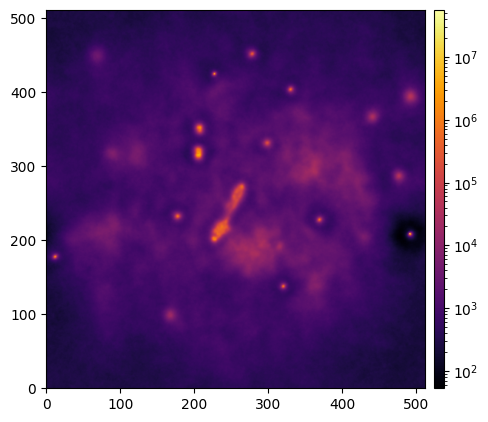

In [32]:
lh_dct = dict(
    data = data,
    model = fast_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

fast_samples, _ = optimize_kl(
    likelihood=lh_dct,
    key=4,
    n_total_iterations=1,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=50,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()
split fft shape: (576, 576)
split fft shape: (576, 576)
split fft shape: (576, 576)
split fft shape: (576, 576)


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+1.3881e+05
OPTIMIZE_KL: #(KL minimization steps) 50
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±     0.0, avg:   +0.026±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
sig i0 asperity         :: 'reduced χ²: 3.5e-05±     0.0, avg:  +0.0059±     0.0, #dof:      1'
sig i0 flexibility      :: 'reduced χ²:   0.004±     0.0, avg:   +0.063±     0.0, #dof:      1'
sig i0 fluctuations     :: 'reduced χ²:     5.6±     0.0, avg:     +2.4±     0.0, #dof:      1'
sig i0 loglogavgslope   :: 'reduced χ²:    0.16±     0.0, avg:     +0.4±     0.0, #dof:      1'
sig i0 spectrum         :: 'reduced χ²: 0.00012±     0.0, avg:  -0.0015±     0.0, #dof:  44048'
sig i0 xi               :: 'reduced χ²: 0.00025±     0.0, avg: +7.1e-07±     0.0, #dof: 262144'
sig i0 zeromode         :: 'reduced χ²:     1.9±     0.0, avg:     +1.4±     0.0, #dof:      1'




split fft shape: (576, 576)


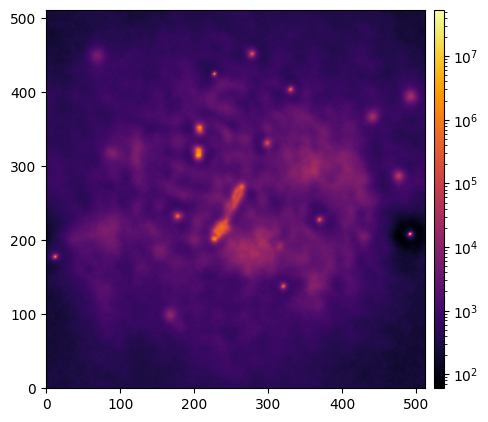

In [33]:
lh_dct = dict(
    data = data,
    model = split_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

split_samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=1,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=50,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)